In [1]:
import os
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
from numpy import NaN
import seaborn as sns

In [2]:
url = '/home/mansi/IOTDATA/IoT Network Intrusion Dataset.csv'
data=pd.read_csv(url)
data.shape

(625783, 86)

In [3]:
data.head(5)

,Flow_ID,Src_IP,Src_Port,Dst_IP,Dst_Port,Protocol,Timestamp,Flow_Duration,Tot_Fwd_Pkts,Tot_Bwd_Pkts,...,Active_Std,Active_Max,Active_Min,Idle_Mean,Idle_Std,Idle_Max,Idle_Min,Label,Cat,Sub_Cat
0,192.168.0.13-192.168.0.16-10000-10101-17,192.168.0.13,10000,192.168.0.16,10101,17,25/07/2019 03:25:53 AM,75,1,1,...,0.0,0.0,0.0,75.0,0.000000,75.0,75.0,Anomaly,Mirai,Mirai-Ackflooding
1,192.168.0.13-222.160.179.132-554-2179-6,222.160.179.132,2179,192.168.0.13,554,6,26/05/2019 10:11:06 PM,5310,1,2,...,0.0,0.0,0.0,2655.0,2261.327486,4254.0,1056.0,Anomaly,DoS,DoS-Synflooding
2,192.168.0.13-192.168.0.16-9020-52727-6,192.168.0.16,52727,192.168.0.13,9020,6,11/07/2019 01:24:48 AM,141,0,3,...,0.0,0.0,0.0,70.5,0.707107,71.0,70.0,Anomaly,Scan,Scan Port OS
3,192.168.0.13-192.168.0.16-9020-52964-6,192.168.0.16,52964,192.168.0.13,9020,6,04/09/2019 03:58:17 AM,151,0,2,...,0.0,0.0,0.0,151.0,0.000000,151.0,151.0,Anomaly,Mirai,Mirai-Hostbruteforceg
4,192.168.0.1-239.255.255.250-36763-1900-17,192.168.0.1,36763,239.255.255.250,1900,17,10/09/2019 01:41:18 AM,153,2,1,...,0.0,0.0,0.0,76.5,0.707107,77.0,76.0,Anomaly,Mirai,Mirai-Hostbruteforceg


In [4]:
# remove attribute 'difficulty_level'
data.drop(['Cat','Sub_Cat'],axis=1,inplace=True)
data.shape

(625783, 84)

In [5]:
data.describe()

,Src_Port,Dst_Port,Protocol,Flow_Duration,Tot_Fwd_Pkts,Tot_Bwd_Pkts,TotLen_Fwd_Pkts,TotLen_Bwd_Pkts,Fwd_Pkt_Len_Max,Fwd_Pkt_Len_Min,...,Fwd_Act_Data_Pkts,Fwd_Seg_Size_Min,Active_Mean,Active_Std,Active_Max,Active_Min,Idle_Mean,Idle_Std,Idle_Max,Idle_Min
count,625783.000000,625783.000000,625783.000000,625783.000000,625783.000000,625783.00000,625783.000000,625783.000000,625783.000000,625783.000000,...,625783.000000,625783.0,625783.000000,625783.000000,625783.000000,625783.000000,625783.000000,625783.000000,625783.000000,625783.000000
mean,35026.156190,16387.027479,9.971436,635.422865,1.675566,1.46853,570.738980,929.280973,392.489726,348.126571,...,1.509913,0.0,3.764405,0.353385,4.248735,3.462159,502.503832,52.403995,561.540512,467.264459
std,24721.047752,17550.363037,5.379857,3496.740723,4.309970,1.21949,1161.873195,1731.760875,619.575865,588.161845,...,4.332737,0.0,68.064508,20.723370,88.934148,64.111043,2112.957360,1153.184897,2866.497606,1931.909971
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.00000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,9020.000000,8899.000000,6.000000,76.000000,0.000000,1.00000,0.000000,18.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,73.000000,0.000000,74.000000,71.000000
50%,51991.000000,9020.000000,6.000000,132.000000,1.000000,1.00000,32.000000,104.000000,30.000000,30.000000,...,1.000000,0.0,0.000000,0.000000,0.000000,0.000000,93.500000,0.000000,114.000000,78.000000
75%,56361.000000,10101.000000,17.000000,221.000000,2.000000,2.00000,1388.000000,1441.000000,1388.000000,386.000000,...,1.000000,0.0,0.000000,0.000000,0.000000,0.000000,141.000000,1.527525,154.000000,130.000000
max,65500.000000,65371.000000,17.000000,99984.000000,186.000000,560.00000,109846.000000,773284.000000,1464.000000,1464.000000,...,186.000000,0.0,9044.625000,8598.658250,26785.000000,6659.000000,99973.000000,67071.906623,99973.000000,99973.000000


In [6]:
# number of attack labels 
data['Label'].value_counts()

Anomaly    585710
Normal      40073
Name: Label, dtype: int64

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 625783 entries, 0 to 625782
Data columns (total 84 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Flow_ID            625783 non-null  object 
 1   Src_IP             625783 non-null  object 
 2   Src_Port           625783 non-null  int64  
 3   Dst_IP             625783 non-null  object 
 4   Dst_Port           625783 non-null  int64  
 5   Protocol           625783 non-null  int64  
 6   Timestamp          625783 non-null  object 
 7   Flow_Duration      625783 non-null  int64  
 8   Tot_Fwd_Pkts       625783 non-null  int64  
 9   Tot_Bwd_Pkts       625783 non-null  int64  
 10  TotLen_Fwd_Pkts    625783 non-null  float64
 11  TotLen_Bwd_Pkts    625783 non-null  float64
 12  Fwd_Pkt_Len_Max    625783 non-null  float64
 13  Fwd_Pkt_Len_Min    625783 non-null  float64
 14  Fwd_Pkt_Len_Mean   625783 non-null  float64
 15  Fwd_Pkt_Len_Std    625783 non-null  float64
 16  Bw

In [8]:
dataset = data['Label']


/home/mansi/anaconda3/lib/python3.9/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


(array([0, 1]), [Text(0, 0, 'Anomaly'), Text(1, 0, 'Normal')])

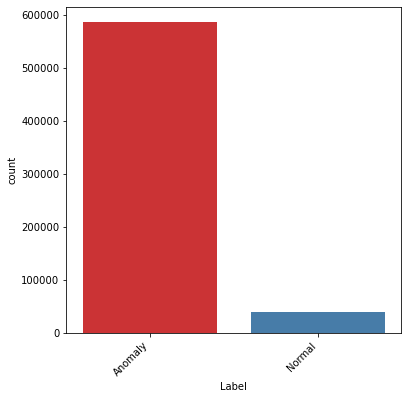

In [9]:
plt.figure(figsize=(6,6))
chart = sns.countplot(dataset, palette="Set1")
plt.xticks(rotation=45, horizontalalignment="right")

In [10]:
# Checking if there are any NULL values in the dataset.

data.isnull().values.any()

False

In [11]:
# Checking which column/s contain NULL values.

[col for col in data if data[col].isnull().values.any()]

[]

In [12]:

from sklearn.preprocessing import OrdinalEncoder

ord_enc = OrdinalEncoder()
data["Flow_ID"] = ord_enc.fit_transform(data[["Flow_ID"]])
data["Src_IP"] = ord_enc.fit_transform(data[["Src_IP"]])
data["Dst_IP"] = ord_enc.fit_transform(data[["Dst_IP"]])
data["Timestamp"] = ord_enc.fit_transform(data[["Timestamp"]])

In [13]:
# Drop the repeated rows
df=data.drop_duplicates()

In [14]:
df.head(5)

,Flow_ID,Src_IP,Src_Port,Dst_IP,Dst_Port,Protocol,Timestamp,Flow_Duration,Tot_Fwd_Pkts,Tot_Bwd_Pkts,...,Fwd_Seg_Size_Min,Active_Mean,Active_Std,Active_Max,Active_Min,Idle_Mean,Idle_Std,Idle_Max,Idle_Min,Label
0,12446.0,25883.0,10000,203.0,10101,17,3496.0,75,1,1,...,0,0.0,0.0,0.0,0.0,75.0,0.000000,75.0,75.0,Anomaly
1,22760.0,34617.0,2179,200.0,554,6,3664.0,5310,1,2,...,0,0.0,0.0,0.0,0.0,2655.0,2261.327486,4254.0,1056.0,Anomaly
2,12691.0,25886.0,52727,200.0,9020,6,2082.0,141,0,3,...,0,0.0,0.0,0.0,0.0,70.5,0.707107,71.0,70.0,Anomaly
3,12704.0,25886.0,52964,200.0,9020,6,791.0,151,0,2,...,0,0.0,0.0,0.0,0.0,151.0,0.000000,151.0,151.0,Anomaly
4,611.0,25881.0,36763,317.0,1900,17,1040.0,153,2,1,...,0,0.0,0.0,0.0,0.0,76.5,0.707107,77.0,76.0,Anomaly


In [15]:
labl = df['Label']
dataset = df.loc[:, df.columns != 'Label'].astype('float64')

In [16]:
# Checking if all values are finite.

np.all(np.isfinite(dataset))

False

In [17]:
# Checking what column/s contain non-finite values.

nonfinite = [col for col in dataset if not np.all(np.isfinite(dataset[col]))]

nonfinite

['Flow_Byts/s', 'Flow_Pkts/s']

In [18]:
# Checking how many non-finite values each column contains.

finite = np.isfinite(dataset['Flow_Byts/s']).sum()

dataset.shape[0] - finite

323

In [19]:
# Checking how many non-finite values each column contains.

finite = np.isfinite(dataset['Flow_Pkts/s']).sum()

dataset.shape[0] - finite

323

In [20]:
# Same as before, since there is a small number of non-finite values we can safely remove them from the dataset
# without spoiling the dataset.

# Replacing infinite values with NaN values.
dataset = dataset.replace([np.inf, -np.inf], np.nan)

In [21]:
# We can see that now we have Nan values again.

np.any(np.isnan(dataset))

True

In [22]:
# Bringing the Labels back into the dataset before deliting Nan rows.

dataset = dataset.merge(labl, how='outer', left_index=True, right_index=True)

In [23]:
# Removing new NaN values.

dataset.dropna(inplace=True)

In [24]:
dataset.shape

(411382, 84)

In [25]:
dataset.head()

,Flow_ID,Src_IP,Src_Port,Dst_IP,Dst_Port,Protocol,Timestamp,Flow_Duration,Tot_Fwd_Pkts,Tot_Bwd_Pkts,...,Fwd_Seg_Size_Min,Active_Mean,Active_Std,Active_Max,Active_Min,Idle_Mean,Idle_Std,Idle_Max,Idle_Min,Label
0,12446.0,25883.0,10000.0,203.0,10101.0,17.0,3496.0,75.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,75.0,0.000000,75.0,75.0,Anomaly
1,22760.0,34617.0,2179.0,200.0,554.0,6.0,3664.0,5310.0,1.0,2.0,...,0.0,0.0,0.0,0.0,0.0,2655.0,2261.327486,4254.0,1056.0,Anomaly
2,12691.0,25886.0,52727.0,200.0,9020.0,6.0,2082.0,141.0,0.0,3.0,...,0.0,0.0,0.0,0.0,0.0,70.5,0.707107,71.0,70.0,Anomaly
3,12704.0,25886.0,52964.0,200.0,9020.0,6.0,791.0,151.0,0.0,2.0,...,0.0,0.0,0.0,0.0,0.0,151.0,0.000000,151.0,151.0,Anomaly
4,611.0,25881.0,36763.0,317.0,1900.0,17.0,1040.0,153.0,2.0,1.0,...,0.0,0.0,0.0,0.0,0.0,76.5,0.707107,77.0,76.0,Anomaly


/home/mansi/anaconda3/lib/python3.9/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


(array([0, 1]), [Text(0, 0, 'Anomaly'), Text(1, 0, 'Normal')])

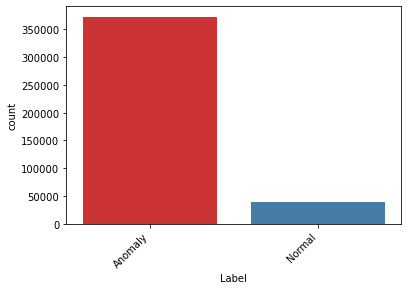

In [26]:
data= dataset['Label']
plt.figure()
chart = sns.countplot(data, palette="Set1")
plt.xticks(rotation=45, horizontalalignment="right")

In [27]:
dataset['Label'].value_counts()

Anomaly    372784
Normal      38598
Name: Label, dtype: int64

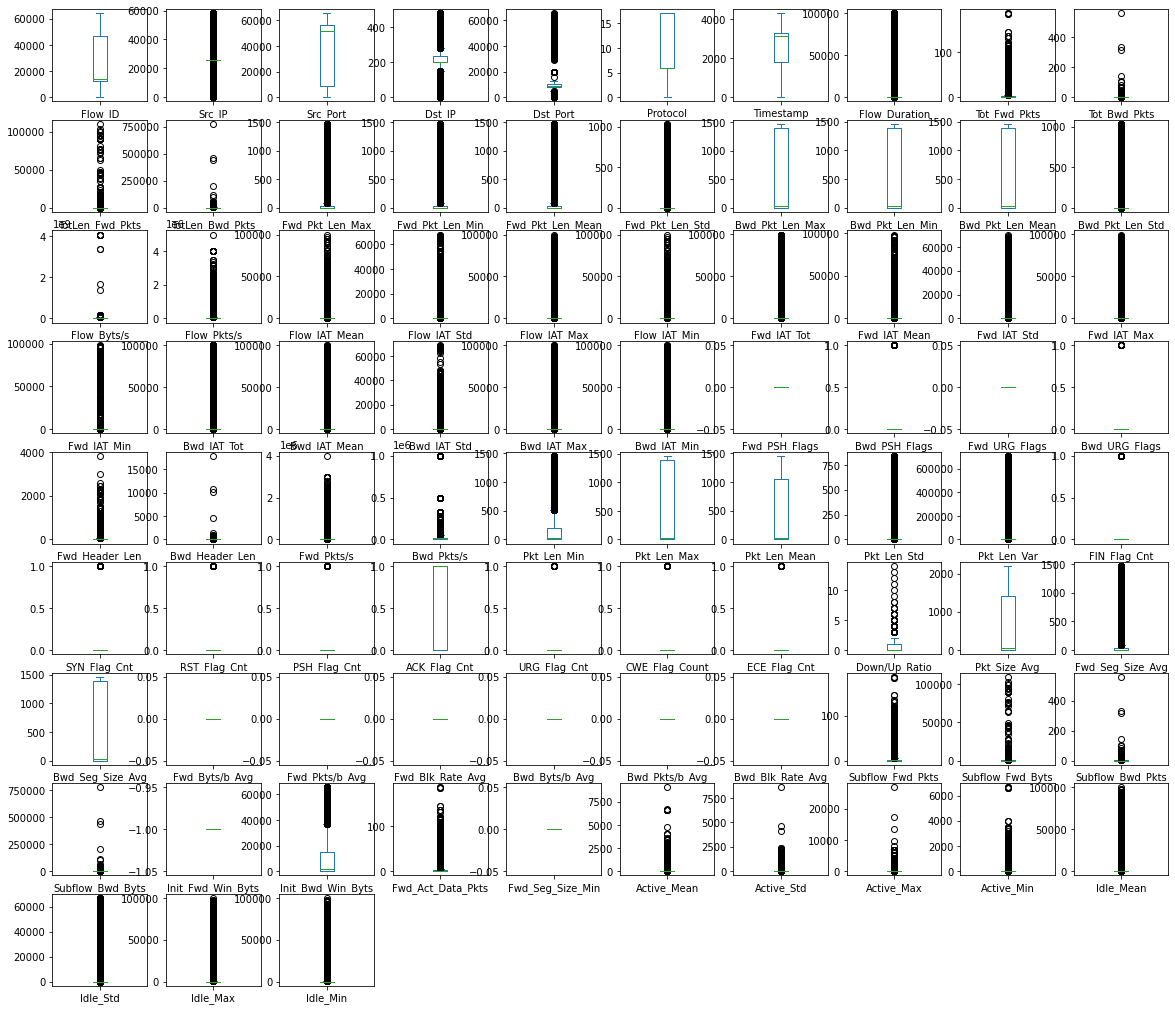

In [28]:
# box and whisker plot for outliers

dataset.plot(kind="box",subplots=True, layout=(10,10),sharex=False,sharey=False,figsize=(20,20))
plt.show()

In [29]:
labels = dataset['Label']
features = dataset.loc[:, dataset.columns != 'Label'].astype('float64')

In [30]:
# For scaling the data, we use RobustScaler class from sklearn.

from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
scaler.fit(features)

features = scaler.transform(features)

In [31]:
from sklearn.preprocessing import LabelEncoder

LE = LabelEncoder()

LE.fit(labels)
labels = LE.transform(labels)

In [32]:
np.unique(labels)

array([0, 1])

In [33]:
# binary classification ##
 #changing attack category

bin_label = pd.DataFrame(dataset.Label.map(lambda x:'Normal' if x=='Normal' else 'ATTACK'))

In [34]:
bin_data = dataset.copy()
bin_data['Label'] = bin_label

In [35]:
LE1 = LabelEncoder()

enc_label = bin_label.apply(LE1.fit_transform)
bin_data['intrusion']= enc_label

In [36]:
LE1.classes_

array(['ATTACK', 'Normal'], dtype=object)

In [37]:
# one-hot-encoding for attack label

bin_data = pd.get_dummies(bin_data,columns=['Label'],prefix="",prefix_sep="")
bin_data['Label']= bin_label
bin_data

,Flow_ID,Src_IP,Src_Port,Dst_IP,Dst_Port,Protocol,Timestamp,Flow_Duration,Tot_Fwd_Pkts,Tot_Bwd_Pkts,...,Active_Max,Active_Min,Idle_Mean,Idle_Std,Idle_Max,Idle_Min,intrusion,ATTACK,Normal,Label
0,12446.0,25883.0,10000.0,203.0,10101.0,17.0,3496.0,75.0,1.0,1.0,...,0.0,0.0,75.0,0.000000,75.0,75.0,0,1,0,ATTACK
1,22760.0,34617.0,2179.0,200.0,554.0,6.0,3664.0,5310.0,1.0,2.0,...,0.0,0.0,2655.0,2261.327486,4254.0,1056.0,0,1,0,ATTACK
2,12691.0,25886.0,52727.0,200.0,9020.0,6.0,2082.0,141.0,0.0,3.0,...,0.0,0.0,70.5,0.707107,71.0,70.0,0,1,0,ATTACK
3,12704.0,25886.0,52964.0,200.0,9020.0,6.0,791.0,151.0,0.0,2.0,...,0.0,0.0,151.0,0.000000,151.0,151.0,0,1,0,ATTACK
4,611.0,25881.0,36763.0,317.0,1900.0,17.0,1040.0,153.0,2.0,1.0,...,0.0,0.0,76.5,0.707107,77.0,76.0,0,1,0,ATTACK
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
625773,62439.0,25889.0,60165.0,233.0,8899.0,17.0,3245.0,29.0,5.0,1.0,...,0.0,0.0,5.8,3.346640,11.0,3.0,0,1,0,ATTACK
625776,58871.0,21034.0,8739.0,205.0,19604.0,6.0,535.0,1092.0,0.0,2.0,...,0.0,0.0,1092.0,0.000000,1092.0,1092.0,0,1,0,ATTACK
625778,62081.0,25889.0,56112.0,233.0,8043.0,17.0,3443.0,277.0,1.0,1.0,...,0.0,0.0,277.0,0.000000,277.0,277.0,0,1,0,ATTACK
625779,18760.0,30623.0,4570.0,200.0,554.0,6.0,3637.0,1658.0,0.0,2.0,...,0.0,0.0,1658.0,0.000000,1658.0,1658.0,0,1,0,ATTACK


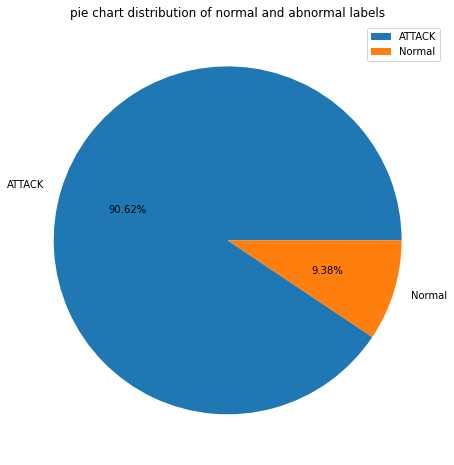

In [38]:
# attack distribution for binary

plt.figure(figsize=(8,8))
plt.pie(bin_data.Label.value_counts(),labels=bin_data.Label.unique(),autopct='%0.2f%%')
plt.title("pie chart distribution of normal and abnormal labels")
plt.legend()
plt.show()

In [39]:
# creating dataframe with only numeric attributes of binary class and encoded label attribute
numeric_col = dataset.select_dtypes(include = 'number').columns

numeric_bin = bin_data[numeric_col]
numeric_bin['intrusion'] = bin_data['intrusion']

/tmp/ipykernel_620590/1352549749.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  numeric_bin['intrusion'] = bin_data['intrusion']


In [40]:
# extracting features which have more than 0.5 correlation (pearson correlation coefficient)

corr=numeric_bin.corr()
corr_y = abs(corr['intrusion'])
highest_corr = corr_y[corr_y >0.2]
highest_corr.sort_values(ascending=True)

Bwd_Pkt_Len_Max     0.200683
Pkt_Len_Max         0.204781
Bwd_Pkt_Len_Min     0.214931
Bwd_Pkt_Len_Mean    0.215361
Bwd_Seg_Size_Avg    0.215361
Protocol            0.221809
TotLen_Fwd_Pkts     0.240765
Subflow_Fwd_Byts    0.240765
Fwd_Pkt_Len_Mean    0.264598
Fwd_Seg_Size_Avg    0.264598
Src_Port            0.283235
ACK_Flag_Cnt        0.313216
Fwd_Pkt_Len_Max     0.315905
Fwd_Pkt_Len_Std     0.371807
Dst_Port            0.511449
intrusion           1.000000
Name: intrusion, dtype: float64

In [41]:
numeric_bin = bin_data[['Bwd_Pkt_Len_Max','Pkt_Len_Max','Bwd_Pkt_Len_Min','Bwd_Pkt_Len_Mean','Bwd_Seg_Size_Avg',
                        'Protocol','TotLen_Fwd_Pkts','Subflow_Fwd_Byts','Fwd_Pkt_Len_Mean','Fwd_Seg_Size_Avg',
                        'Src_Port','ACK_Flag_Cnt','Fwd_Pkt_Len_Max','Fwd_Pkt_Len_Std','Dst_Port']]

In [42]:
bin_data = numeric_bin.join(bin_data[['intrusion','Normal','ATTACK','Label']])

In [43]:
bin_data

,Bwd_Pkt_Len_Max,Pkt_Len_Max,Bwd_Pkt_Len_Min,Bwd_Pkt_Len_Mean,Bwd_Seg_Size_Avg,Protocol,TotLen_Fwd_Pkts,Subflow_Fwd_Byts,Fwd_Pkt_Len_Mean,Fwd_Seg_Size_Avg,Src_Port,ACK_Flag_Cnt,Fwd_Pkt_Len_Max,Fwd_Pkt_Len_Std,Dst_Port,intrusion,Normal,ATTACK,Label
0,1430.0,1430.0,1430.0,1430.000000,1430.000000,17.0,982.0,982.0,982.0,982.0,10000.0,0.0,982.0,0.000000,10101.0,0,0,1,ATTACK
1,0.0,0.0,0.0,0.000000,0.000000,6.0,0.0,0.0,0.0,0.0,2179.0,0.0,0.0,0.000000,554.0,0,0,1,ATTACK
2,1388.0,1388.0,30.0,935.333333,935.333333,6.0,0.0,0.0,0.0,0.0,52727.0,1.0,0.0,0.000000,9020.0,0,0,1,ATTACK
3,1388.0,1388.0,1388.0,1388.000000,1388.000000,6.0,0.0,0.0,0.0,0.0,52964.0,1.0,0.0,0.000000,9020.0,0,0,1,ATTACK
4,420.0,452.0,420.0,420.000000,420.000000,17.0,886.0,886.0,443.0,443.0,36763.0,0.0,452.0,12.727922,1900.0,0,0,1,ATTACK
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
625773,32.0,32.0,32.0,32.000000,32.000000,17.0,160.0,160.0,32.0,32.0,60165.0,0.0,32.0,0.000000,8899.0,0,0,1,ATTACK
625776,0.0,0.0,0.0,0.000000,0.000000,6.0,0.0,0.0,0.0,0.0,8739.0,0.0,0.0,0.000000,19604.0,0,0,1,ATTACK
625778,18.0,18.0,18.0,18.000000,18.000000,17.0,18.0,18.0,18.0,18.0,56112.0,0.0,18.0,0.000000,8043.0,0,0,1,ATTACK
625779,0.0,0.0,0.0,0.000000,0.000000,6.0,0.0,0.0,0.0,0.0,4570.0,0.0,0.0,0.000000,554.0,0,0,1,ATTACK


In [44]:
bin_data['intrusion'].value_counts()

0    372784
1     38598
Name: intrusion, dtype: int64

In [45]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, roc_curve,auc
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn import svm
from sklearn.ensemble import ExtraTreesClassifier
import time
import warnings


In [46]:
# classifier for binary classification dataset

warnings.filterwarnings("ignore")


X = bin_data.iloc[:,0:15].to_numpy() # dataset excluding target attribute (encoded, one-hot-encoded,original)
y = bin_data['intrusion'] # target attribute

X_train, X_validation, Y_train, Y_validation = train_test_split(X, y, test_size=0.20, random_state=1)
# Spot Check Algorithms
models = []
models.append(('LR', LogisticRegression(solver='liblinear', multi_class='ovr')))
models.append(('LDA', LinearDiscriminantAnalysis()))
models.append(('KNN', KNeighborsClassifier()))
models.append(('CART', DecisionTreeClassifier()))
#models.append(('NB', GaussianNB()))
models.append(('SVM', SVC(max_iter=1000,gamma='auto')))

print ('Model\tAcc\tpr\tRecall\tF1\tFAR\tsen\tspe\tExecution_time')

# evaluate each model in turn
results = []
names = []

for name, model in models:
    start_time = time.time()
    kfold = StratifiedKFold(n_splits=10, random_state=1, shuffle=True)
    
    cv_results = cross_val_score(model, X_train, Y_train, cv=kfold, scoring='accuracy').mean()
    precision = cross_val_score(model, X_train, Y_train, cv=kfold, scoring='precision').mean()
    recall = cross_val_score(model, X_train, Y_train, cv=kfold, scoring='recall').mean()
    f1score = cross_val_score(model, X_train, Y_train, cv=kfold, scoring='f1_weighted').mean()
    
    m = model.fit(X_train, Y_train)
    predict = m.predict(X_validation)
    cm = confusion_matrix(Y_validation, predict)
    # Creating a dataframe for a array-formatted Confusion matrix,so it will be easy for plotting.
    cm_df = pd.DataFrame(cm)
    
    total1=sum(sum(cm))
    false_alaram_rate = cm[1,0]/(cm[1,0]+cm[0,0])
    sensitivity = cm[1,1]/(cm[1,1]+cm[0,1])
    specificity = cm[0,0]/(cm[1,0]+cm[0,0])
    
    delta = time.time()- start_time
    results.append(cv_results)
    names.append(name)
    print('{}\t{:.3f}\t{:.3f}\t{:.3f}\t{:.3f}\t{:.3f}\t{:.3f}\t{:.3f}\t{:.2f} sec'.format(name, cv_results, precision, recall, f1score, false_alaram_rate, sensitivity, specificity, delta))
    print(cm_df)
    

Model	Acc	pr	Recall	F1	FAR	sen	spe	Execution_time
LR	0.917	0.654	0.238	0.899	0.075	0.658	0.925	289.81 sec
       0     1
0  73522   958
1   5956  1841
LDA	0.919	0.579	0.511	0.917	0.051	0.585	0.949	30.14 sec
       0     1
0  71694  2786
1   3871  3926
KNN	0.998	0.995	0.988	0.998	0.001	0.996	0.999	399.71 sec
       0     1
0  74451    29
1    106  7691
CART	0.999	0.997	0.995	0.999	0.001	0.997	0.999	52.12 sec
       0     1
0  74454    26
1     38  7759
SVM	0.939	0.674	0.961	0.947	0.000	0.541	1.000	1636.11 sec
       0     1
0  67896  6584
1     29  7768


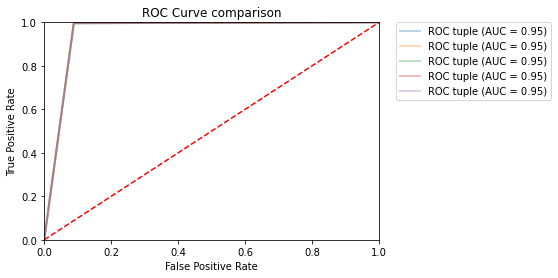

In [47]:
#Creating plot to show the ROC for all models


index = 1
for model in models:
    fp, tp, th = roc_curve(Y_validation, predict)
    roc_auc_mla = auc(fp, tp)
    MLA_name = model.__class__.__name__
    plt.plot(fp, tp, lw=2, alpha=0.3, label='ROC %s (AUC = %0.2f)'  % (MLA_name, roc_auc_mla))
index+=1

plt.title('ROC Curve comparison')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.plot([0,1],[0,1],'r--')
plt.xlim([0,1])
plt.ylim([0,1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')    
plt.show()